# IE6600 Computation and Visualization for Analytics
### Interactive Data Visualization - Part 3

#### -- STUDENT VERSION --

#### Exercise 1 Creating a Static Bar Plot and Calculating the Mean and Standard Deviation in Temporal Data

In [1]:
import pandas as pd
import numpy as np
import warnings 

# Settings the warnings to be ignored 
warnings.filterwarnings('ignore')

passenger_df = pd.read_csv("airline-passengers.csv")
passenger_df["Date"] = pd.to_datetime(passenger_df["Date"])
passenger_df

,Date,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [2]:
# Extract month, day, and day-name columns from the Date column:
passenger_df["month"] = passenger_df["Date"].dt.month 
passenger_df["day"] = passenger_df["Date"].dt.day 
passenger_df["day_name"] = passenger_df["Date"].dt.day_name()
passenger_df.head()

,Date,#Passengers,month,day,day_name
0,1949-01-01,112,1,1,Saturday
1,1949-02-01,118,2,1,Tuesday
2,1949-03-01,132,3,1,Tuesday
3,1949-04-01,129,4,1,Friday
4,1949-05-01,121,5,1,Sunday


In [3]:
# Aggregate the #Passengers column by the month column:
passenger_per_month = passenger_df.groupby(["month"])[["#Passengers"]].agg("sum")
passenger_per_month = passenger_per_month.reset_index()
passenger_per_month

,month,#Passengers
0,1,2901
1,2,2820
2,3,3242
3,4,3205
4,5,3262
5,6,3740
6,7,4216
7,8,4213
8,9,3629
9,10,3199


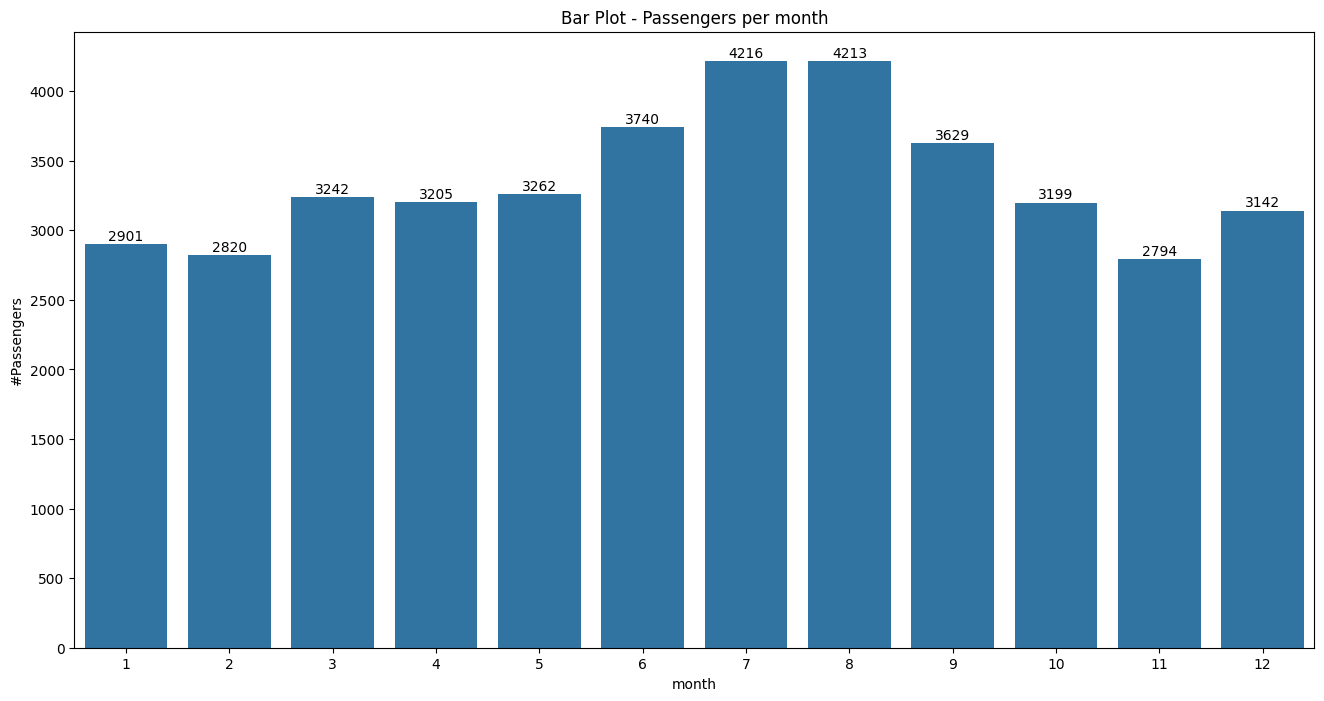

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))

# --- Added the code here ---
ax = sns.barplot(x="month",y="#Passengers", data=passenger_per_month)
# ---------------------------

ax.set_title("Bar Plot - Passengers per month")

#Annotate the bars with value to have better idea
for p, v in zip(ax.patches, passenger_per_month['#Passengers']):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height + 5, v,
                 ha='center', va='bottom')
plt.show()


In [5]:
# Calculate the mean of #Passengers per month using the following code:
mean_passengers_per_month = passenger_df.groupby(["month"])[["#Passengers"]].agg("mean").reset_index()
mean_passengers_per_month.head()

,month,#Passengers
0,1,241.750000
1,2,235.000000
2,3,270.166667
3,4,267.083333
4,5,271.833333


In [6]:
# Calculate the median of #Passengers per month using the following code:
median_passengers_per_month = passenger_df.groupby(["month"])[["#Passengers"]].agg("median").reset_index()
median_passengers_per_month.head()

,month,#Passengers
0,1,223.0
1,2,214.5
2,3,251.5
3,4,252.0
4,5,252.0


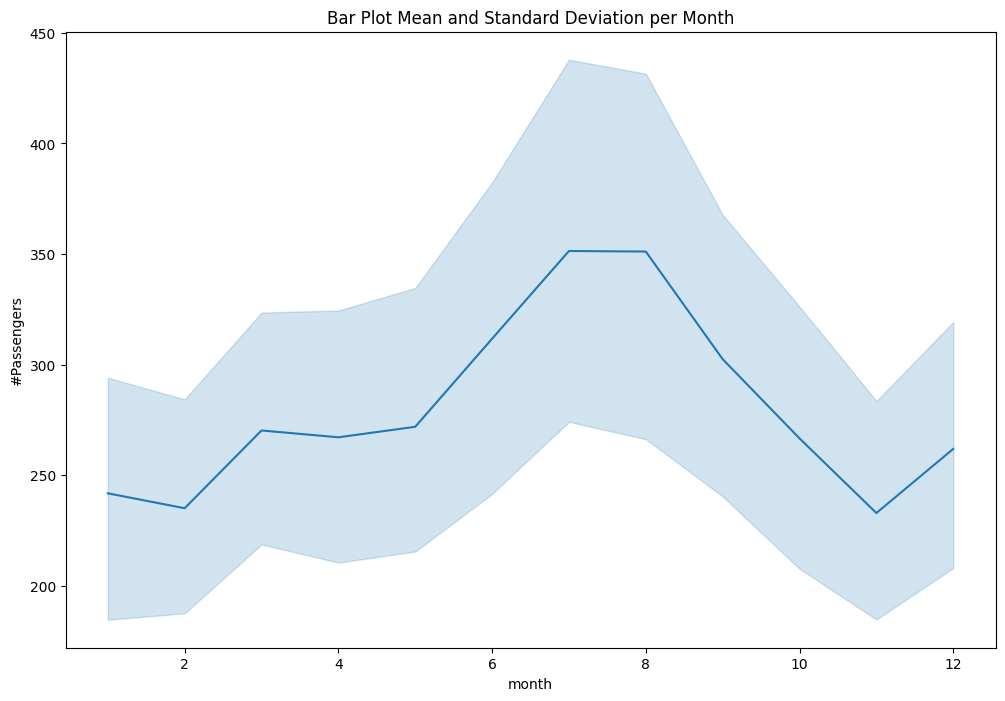

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

# --- Added the code here ---
ax = sns.lineplot(x="month",y="#Passengers", data=passenger_df)
# ---------------------------

ax.set_title("Bar Plot Mean and Standard Deviation per Month")
plt.show()

#### Exercise 2 Calculating z-score to Find Outliers in Temporal Data

In [8]:
import pandas as pd
import numpy as np

passenger_df = pd.read_csv("airline-passengers.csv")
passenger_df["Date"] = pd.to_datetime(passenger_df["Date"])

# Calculate the mean and standard deviation of the #Passengers column 
passenger_df['mean'] = passenger_df["#Passengers"].mean()
passenger_df['std'] = passenger_df["#Passengers"].std()

# --- Added the code here ---
# Calculate the zscore 
passenger_df['zscore'] = (passenger_df["#Passengers"] - passenger_df['mean'])/passenger_df['std']
# Now apply the abs function to calculate the absolute value of zscore:
passenger_df['zscore_abs'] = passenger_df['zscore'].abs()
# ---------------------------

# Sort the DataFrame by zscore_abs:
passenger_df.sort_values(by="zscore_abs", ascending=False).head(100)


,Date,#Passengers,mean,std,zscore,zscore_abs
138,1960-07-01,622,280.298611,119.966317,2.848311,2.848311
139,1960-08-01,606,280.298611,119.966317,2.714940,2.714940
127,1959-08-01,559,280.298611,119.966317,2.323164,2.323164
126,1959-07-01,548,280.298611,119.966317,2.231471,2.231471
137,1960-06-01,535,280.298611,119.966317,2.123108,2.123108
...,...,...,...,...,...,...
111,1958-04-01,348,280.298611,119.966317,0.564337,0.564337
105,1957-10-01,347,280.298611,119.966317,0.556001,0.556001
79,1955-08-01,347,280.298611,119.966317,0.556001,0.556001
41,1952-06-01,218,280.298611,119.966317,-0.519301,0.519301


In [9]:
# First, filter the high and low values using the zscore:
anamlous_df_high = passenger_df.sort_values(by="zscore", ascending=False).head(10)
anamlous_df_high["Date"] = pd.to_datetime(anamlous_df_high["Date"])
anamlous_df_low = passenger_df.sort_values(by="zscore", ascending=True).head(10)
anamlous_df_low["Date"] = pd.to_datetime(anamlous_df_low["Date"])

In [10]:
# Show the outliers with the high values
anamlous_df_high

,Date,#Passengers,mean,std,zscore,zscore_abs
138,1960-07-01,622,280.298611,119.966317,2.848311,2.848311
139,1960-08-01,606,280.298611,119.966317,2.714940,2.714940
127,1959-08-01,559,280.298611,119.966317,2.323164,2.323164
126,1959-07-01,548,280.298611,119.966317,2.231471,2.231471
137,1960-06-01,535,280.298611,119.966317,2.123108,2.123108
140,1960-09-01,508,280.298611,119.966317,1.898044,1.898044
115,1958-08-01,505,280.298611,119.966317,1.873037,1.873037
114,1958-07-01,491,280.298611,119.966317,1.756338,1.756338
136,1960-05-01,472,280.298611,119.966317,1.597960,1.597960
125,1959-06-01,472,280.298611,119.966317,1.597960,1.597960


In [11]:
# Show the outliers with the low values
anamlous_df_low

,Date,#Passengers,mean,std,zscore,zscore_abs
10,1949-11-01,104,280.298611,119.966317,-1.469568,1.469568
0,1949-01-01,112,280.298611,119.966317,-1.402882,1.402882
22,1950-11-01,114,280.298611,119.966317,-1.386211,1.386211
12,1950-01-01,115,280.298611,119.966317,-1.377875,1.377875
11,1949-12-01,118,280.298611,119.966317,-1.352868,1.352868
1,1949-02-01,118,280.298611,119.966317,-1.352868,1.352868
9,1949-10-01,119,280.298611,119.966317,-1.344532,1.344532
4,1949-05-01,121,280.298611,119.966317,-1.327861,1.327861
16,1950-05-01,125,280.298611,119.966317,-1.294518,1.294518
13,1950-02-01,126,280.298611,119.966317,-1.286183,1.286183


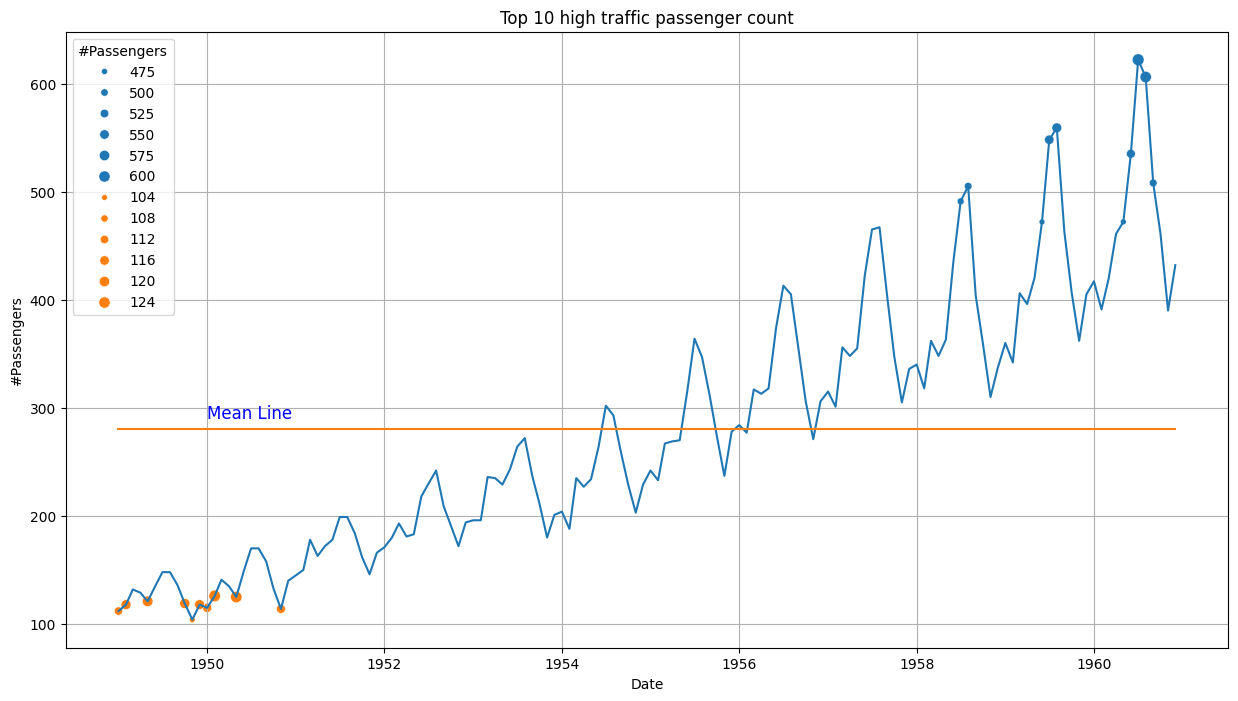

In [12]:
# Plot the outliers
import seaborn as sns
import matplotlib.pyplot as plt
       
plt.figure(figsize=(15,8))
plt.grid=True
plt.title("Top 10 high traffic passenger count")
ax = sns.lineplot(x="Date", y="#Passengers", data=passenger_df)

# --- Added the code here ---
ax = sns.scatterplot(x="Date",y="#Passengers", data=anamlous_df_high, size="#Passengers")
# ---------------------------

ax = sns.lineplot(x="Date", y="mean", data=passenger_df)
ax.text(pd.to_datetime("1950"), 290, "Mean Line",
            horizontalalignment='left', size='large', color='Blue')

# --- Added the code here ---
ax = sns.scatterplot(x="Date",y="#Passengers", data=anamlous_df_low, size="#Passengers")
# ---------------------------

ax.grid()


#### Exercise 3 Upsampling and Downsampling in Temporal Data

In [13]:
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd

# Read the dataset using pandas and drop the NA values:
walmart_stores = pd.read_csv('1962_2006_walmart_store_openings.csv',
                   parse_dates=['date_super']).dropna()
walmart_stores.head()

,storenum,OPENDATE,date_super,conversion,st,county,STREETADDR,STRCITY,STRSTATE,ZIPCODE,type_store,LAT,LON,MONTH,DAY,YEAR
0,1,7/1/62,1997-03-01,1.0,5,7,2110 WEST WALNUT,Rogers,AR,72756,Supercenter,36.342235,-94.07141,7,1,1962
1,2,8/1/64,1996-03-01,1.0,5,9,1417 HWY 62/65 N,Harrison,AR,72601,Supercenter,36.236984,-93.09345,8,1,1964
2,4,8/1/65,2002-03-01,1.0,5,7,2901 HWY 412 EAST,Siloam Springs,AR,72761,Supercenter,36.179905,-94.50208,8,1,1965
3,8,10/1/67,1993-03-01,1.0,5,29,1621 NORTH BUSINESS 9,Morrilton,AR,72110,Supercenter,35.156491,-92.75858,10,1,1967
5,10,7/1/68,1998-03-01,1.0,40,21,2020 SOUTH MUSKOGEE,Tahlequah,OK,74464,Supercenter,35.923658,-94.97185,7,1,1968


In [14]:
# Count the number of stores opened per year
walmart_store_count = walmart_stores.groupby("YEAR")[["storenum"]].agg("count")\
                        .rename(columns={"storenum": "store_count"})

print(walmart_store_count)

      store_count
YEAR             
1962            1
1964            1
1965            1
1967            1
1968            5
1969            4
1970            4
1971           14
1972           13
1973           14
1974           20
1975           14
1976           17
1977           29
1978           24
1979           37
1980           33
1981          117
1982           42
1983           65
1984           79
1985           80
1986           90
1987           92
1988           82
1989           86
1990          106
1991           71
1992           60
1993           52
1994           36
1995           46
1996           19
1997           26
1998           33
1999           47
2000           78
2001           69
2002           65
2003           63
2004           90
2005           87
2006           33


In [15]:
# Merge walmart_store_count with walmart_stores
walmart_store_count = pd.merge(walmart_stores, walmart_store_count, on="YEAR")

# Set the index with date_super
walmart_store_count= walmart_store_count.set_index(pd.\
     DatetimeIndex(walmart_store_count.date_super))

# Filter out the required columns
walmart_store_count = walmart_store_count[["date_super", "store_count"]] 
walmart_store_count.drop_duplicates(subset="date_super", inplace=True)

# Print the DataFrame
walmart_store_count.head(8)

,date_super,store_count
date_super,,
1997-03-01,1997-03-01,1
1996-03-01,1996-03-01,1
2002-03-01,2002-03-01,1
1993-03-01,1993-03-01,1
1998-03-01,1998-03-01,5
1994-03-01,1994-03-01,5
2002-02-20,2002-02-20,5
2000-03-01,2000-03-01,5


In [16]:
# Convert the frequency of walmart_store_count_series to 2 days
walmart_store_count_series = walmart_store_count.store_count

# --- Added the code here ---
walmart_store_count_series = walmart_store_count_series.asfreq(freq='2D')
# ---------------------------

walmart_store_count_series.head()


date_super
1988-03-01    14.0
1988-03-03     NaN
1988-03-05     NaN
1988-03-07     NaN
1988-03-09     NaN
Freq: 2D, Name: store_count, dtype: float64

<Axes: xlabel='date_super'>

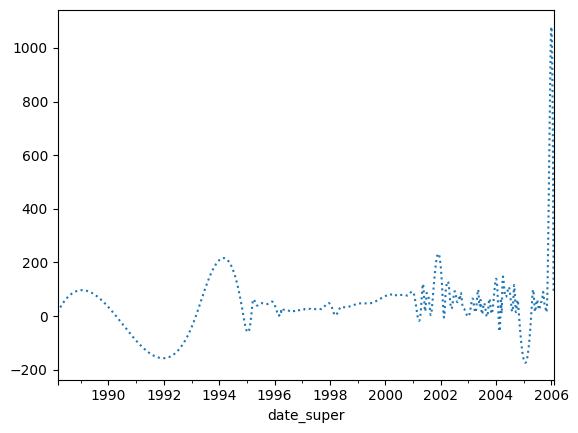

In [17]:
# Interpolate the missing values using Spline interpolation:
# --- Added the code here ---
walmart_store_count_series = walmart_store_count_series.\
       interpolate(method="spline", order=3) 
# ---------------------------

walmart_store_count_series.plot(style=":")


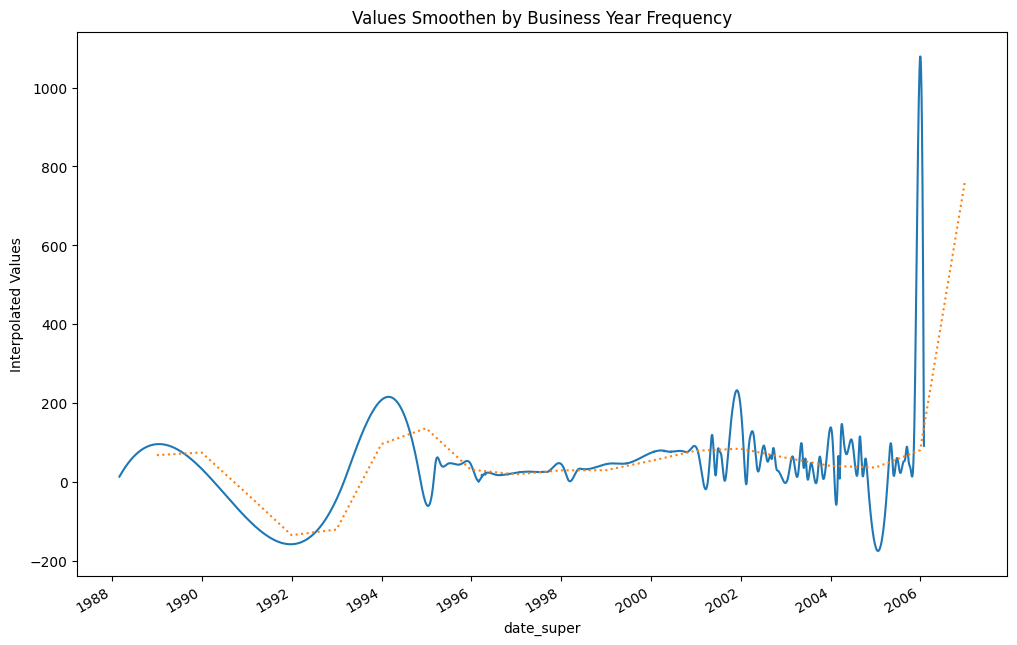

In [18]:
# Smooth out the plot using downsampling 
plt.figure(figsize=(12,8))
plt.ylabel("Interpolated Values")
plt.plot(walmart_store_count_series)

# --- Added the code here ---
# BA stands for Business Year
walmart_store_count_series.resample('BYE').mean().plot(style=':',
     title="Values Smoothen by Business Year Frequency") 
# ---------------------------

plt.show()


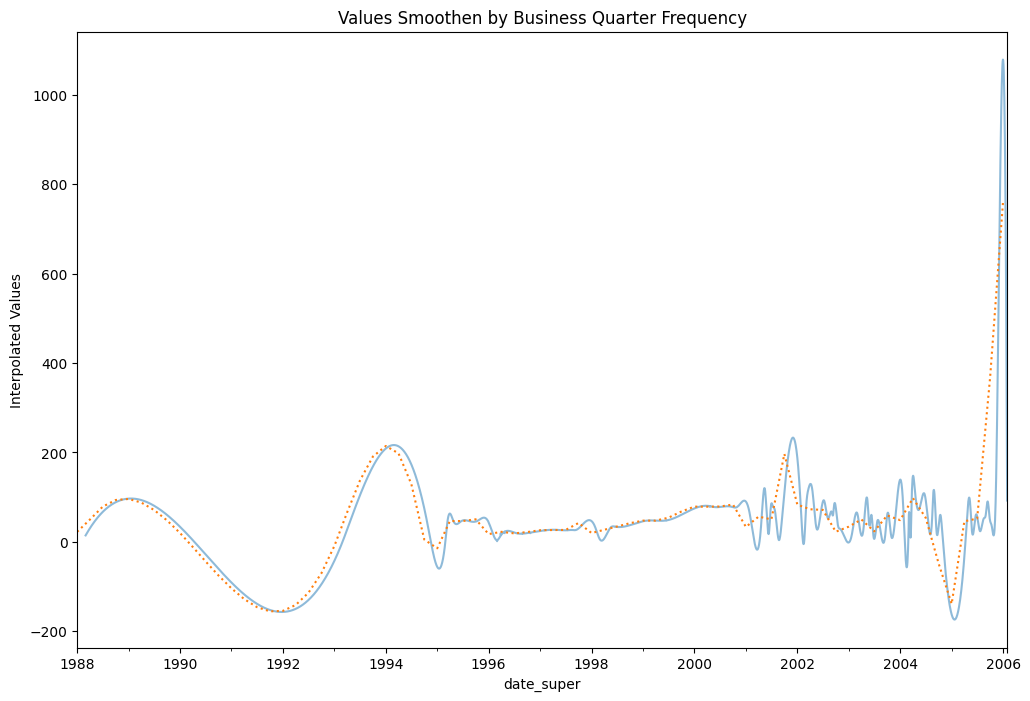

In [19]:
# Downsample with a frequency of BQ (business quarter) to observe more details
plt.figure(figsize=(12,8))
plt.ylabel("Interpolated Values")
walmart_store_count_series.plot(alpha=0.5, style='-')

# --- Added the code here ---
# BQ stands for Business quarter
walmart_store_count_series.resample('BQE').mean().plot(style=':',
       title="Values Smoothen by Business Quarter Frequency")
# ---------------------------

plt.show()


### Interactive Visualization of Geographical Data

#### Exercise 4 Creating a Worldwide Map

In [20]:
import pandas as pd

internet_usage_df = pd.read_csv('share-of-individuals-using-the-internet.csv')
# Subset the data to one specific year - 2016
internet_usage_2016 = internet_usage_df.query("Year==2016")
internet_usage_2016

,Country,Code,Year,Individuals using the Internet (% of population)
16,Afghanistan,AFG,2016,10.595726
39,Albania,ALB,2016,66.363445
63,Algeria,DZA,2016,42.945527
85,Andorra,AND,2016,97.930637
107,Angola,AGO,2016,13.000000
...,...,...,...,...
5960,Vietnam,VNM,2016,46.500000
5985,World,OWID_WRL,2016,45.793684
6007,Yemen,YEM,2016,24.579208
6031,Zambia,ZMB,2016,25.506579


In [21]:
# Generate an interactive world-wide map using plotly library
import plotly.express as px

# --- Added the code here ---
fig = px.choropleth(internet_usage_2016,
        locations="Code", 
        color="Individuals using the Internet (% of population)", 
        hover_name="Country", 
        color_continuous_scale=px.colors.sequential.Plasma)
# ---------------------------

fig.show()        


#### Exercise 5 Tweaking a Worldwide Map

In [22]:
import pandas as pd

internet_usage_df = pd.read_csv('share-of-individuals-using-the-internet.csv')
# Subset the data to one specific year - 2016
internet_usage_2016 = internet_usage_df.query("Year==2016")
internet_usage_2016.head()

,Country,Code,Year,Individuals using the Internet (% of population)
16,Afghanistan,AFG,2016,10.595726
39,Albania,ALB,2016,66.363445
63,Algeria,DZA,2016,42.945527
85,Andorra,AND,2016,97.930637
107,Angola,AGO,2016,13.000000


In [23]:
# Add title text to the choropleth map setting the title_text parameter:

import plotly.express as px

fig = px.choropleth(internet_usage_2016,
                    locations="Code",
                    color="Individuals using the Internet (% of population)", 
                    hover_name="Country", 
                    color_continuous_scale=px.colors.sequential.Plasma)

# add a title text for the plot
# --- Added the code here ---
fig.update_layout()
# ---------------------------

fig.show()

In [24]:
# Set geo_scope to asia in the update_layout function to zoom into the asia region. 

import plotly.express as px
fig = px.choropleth(internet_usage_2016,
                    locations="Code",
                    color="Individuals using the Internet (% of population)", 
                    hover_name="Country", 
                    color_continuous_scale=px.colors.sequential.Plasma)

# --- Added the code here ---
# add a title text for the plot
fig.update_layout(title_text = 'Internet usage across the world (% population) - 2016',
                   geo_scope = 'asia') 
# can be set to north america | south america | africa | asia | europe | usa
# ---------------------------

fig.show()


In [25]:
# Set projection type to natural earth:

import plotly.express as px
fig = px.choropleth(internet_usage_2016,
                    locations="Code",
                    color="Individuals using the Internet (% of population)", 
                    hover_name="Country", 
                    color_continuous_scale=px.colors.sequential.Plasma)

# --- Added the code here ---
# add a title text for the plot
fig.update_layout(title_text = 'Internet usage across the world (% population) - 2016', 
                  geo = dict()) 
# ---------------------------

fig.show()

#### Exercise 6 Adding Animation to a Map

In [26]:
import pandas as pd

internet_usage_df = pd.read_csv('share-of-individuals-using-the-internet.csv')
internet_usage_df.head()

,Country,Code,Year,Individuals using the Internet (% of population)
0,Afghanistan,AFG,1990,0.000000
1,Afghanistan,AFG,2001,0.004723
2,Afghanistan,AFG,2002,0.004561
3,Afghanistan,AFG,2003,0.087891
4,Afghanistan,AFG,2004,0.105809


In [27]:
# Add an animation to the year column using animation_frame=year:

import plotly.express as px

# --- Added the code here ---
fig = px.choropleth(internet_usage_df,
                    locations="Code",
                    color="Individuals using the Internet (% of population)", 
                    hover_name="Country", 
                    animation_frame="Year", 
                    color_continuous_scale=px.colors.sequential.Plasma)
# ---------------------------

# add a title text for the plot
fig.update_layout(title_text = 'Internet usage across the world (% population)', 
                  geo = dict(projection = {'type' : 'natural earth'})) 

fig.show()


In [28]:
# --- Added the code here ---
# Sort the dataset by Year using the following code:
internet_usage_df = internet_usage_df.sort_values("Year")
# ---------------------------

internet_usage_df.head()


,Country,Code,Year,Individuals using the Internet (% of population)
572,Botswana,BWA,1960,0.0
2097,Grenada,GRD,1960,0.0
5433,Thailand,THA,1960,0.0
3414,Maldives,MDV,1960,0.0
5493,Togo,TGO,1960,0.0


In [29]:
# Generate the animated plot again now that the sorting is done:

import plotly.express as px
fig = px.choropleth(internet_usage_df,
                    locations="Code",
                    color="Individuals using the Internet (% of population)", 
                    hover_name="Country", 
                    animation_frame="Year", # column on which to animate !
                    color_continuous_scale=px.colors.sequential.Plasma)

# add a title text for the plot
fig.update_layout(title_text = 'Internet usage across the world (% population)', 
                  geo = dict(projection = {'type' : 'natural earth'})) 

fig.show()

#### Exercise 7 Creating a USA State Map

In [30]:
import pandas as pd

df = pd.read_csv('us_state_population.tsv', sep='\t')
df.head()

,State,Code,2010,2011,2012,2013,2014,2015,2016,2017,2018
0,Alabama,AL,4785448,4798834,4815564,4830460,4842481,4853160,4864745,4875120,4887871
1,Alaska,AK,713906,722038,730399,737045,736307,737547,741504,739786,737438
2,Arizona,AZ,6407774,6473497,6556629,6634999,6733840,6833596,6945452,7048876,7171646
3,Arkansas,AR,2921978,2940407,2952109,2959549,2967726,2978407,2990410,3002997,3013825
4,California,CA,37320903,37641823,37960782,38280824,38625139,38953142,39209127,39399349,39557045


In [31]:
# Use the melt function to convert the data to the desired format:
df = pd.melt(df, id_vars=['State', 'Code'], 
             var_name="Year", 
             value_name="Population")
df.head()

,State,Code,Year,Population
0,Alabama,AL,2010,4785448
1,Alaska,AK,2010,713906
2,Arizona,AZ,2010,6407774
3,Arkansas,AR,2010,2921978
4,California,CA,2010,37320903


In [32]:
import plotly.graph_objects as go

# initialize the figure
# --- Added the code here ---
fig = go.Figure(
               data=go.Choropleth(
               locations=df['Code'], 
               z=df['Population'], 
               locationmode='USA-states', 
               colorscale = 'Blues',
               colorbar_title = "Population",
           )
)
# update layout
fig.update_layout(
           title_text = 'US Population across states',
           geo_scope='usa')
# ---------------------------

fig.show()


#### Exercise 8 Creating a Scatter Plot on a Geographical Map

In [33]:
import pandas as pd

# Read the dataset using pandas and drop the NA values:
walmart_loc_df = pd.read_csv('1962_2006_walmart_store_openings.csv')
walmart_loc_df.head()

,storenum,OPENDATE,date_super,conversion,st,county,STREETADDR,STRCITY,STRSTATE,ZIPCODE,type_store,LAT,LON,MONTH,DAY,YEAR
0,1,7/1/62,3/1/97,1.0,5,7,2110 WEST WALNUT,Rogers,AR,72756,Supercenter,36.342235,-94.07141,7,1,1962
1,2,8/1/64,3/1/96,1.0,5,9,1417 HWY 62/65 N,Harrison,AR,72601,Supercenter,36.236984,-93.09345,8,1,1964
2,4,8/1/65,3/1/02,1.0,5,7,2901 HWY 412 EAST,Siloam Springs,AR,72761,Supercenter,36.179905,-94.50208,8,1,1965
3,8,10/1/67,3/1/93,1.0,5,29,1621 NORTH BUSINESS 9,Morrilton,AR,72110,Supercenter,35.156491,-92.75858,10,1,1967
4,7,10/1/67,NaN,NaN,5,119,3801 CAMP ROBINSON RD.,North Little Rock,AR,72118,Wal-Mart,34.813269,-92.30229,10,1,1967


In [34]:
# Plot the scatter plot using the update_layout function:

import plotly.graph_objects as go

# --- Added the code here ---
fig = go.Figure(data=go.Scattergeo(
               lon = walmart_loc_df['LON'], # column containing longitude information
               lat = walmart_loc_df['LAT'], # column containing latitude information
               text = walmart_loc_df['STREETADDR'], # hovering over the map
               mode = 'markers' 
               ))
# ---------------------------

fig.update_layout(
               title = 'Walmart stores across world',
               geo_scope='usa',
           )
fig.show()


#### Exercise 9 Creating a Bubble Plot on a Map

In [35]:
import pandas as pd

# Read the dataset using pandas and drop the NA values:
walmart_loc_df = pd.read_csv('1962_2006_walmart_store_openings.csv')

# Use the groupby function to compute the number of Walmart stores per state. 
walmart_stores_by_state = walmart_loc_df.groupby('STRSTATE').count()\
                            ['storenum'].reset_index().rename(columns={'storenum':'NUM_STORES'})

walmart_stores_by_state

,STRSTATE,NUM_STORES
0,AL,90
1,AR,81
2,AZ,55
3,CA,159
4,CO,56
5,DE,8
6,FL,175
7,GA,114
8,IA,55
9,ID,17


In [36]:
import plotly.express as px

# --- Added the code here ---
fig = px.scatter_geo(walmart_stores_by_state,
                     locations="STRSTATE", 
                     size="NUM_STORES", 
                     locationmode = 'USA-states',
                     hover_name="STRSTATE",
                     size_max=45)
# ---------------------------

fig.update_layout(
         # add a title text for the plot
         title_text = 'Walmart stores across states in the US',
         # limit plot scope to USA
         geo_scope='usa'
     )   

fig.show()


#### Exercise 10 Creating Line Plots on a Map

In [37]:
import pandas as pd
us_airports_df = pd.read_csv('airports.csv')
us_airports_df

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447
...,...,...,...,...,...,...,...
317,WRG,Wrangell Airport,Wrangell,AK,USA,56.48433,-132.36982
318,WYS,Westerly State Airport,West Yellowstone,MT,USA,44.68840,-111.11764
319,XNA,Northwest Arkansas Regional Airport,Fayetteville/Springdale/Rogers,AR,USA,36.28187,-94.30681
320,YAK,Yakutat Airport,Yakutat,AK,USA,59.50336,-139.66023


In [38]:
# Generate a scatter plot on the US map 
# to indicate the locations of all airports in our dataset

import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Scattergeo(
           locationmode = 'USA-states',
           lon = us_airports_df['LONGITUDE'],
           lat = us_airports_df['LATITUDE'],
           hoverinfo = 'text',
           text = us_airports_df['AIRPORT'],
           mode = 'markers',
           marker = dict(size = 5,color = 'black')))

fig.update_layout(
      title_text = 'Airports in the USA',
      showlegend = False,
      geo = go.layout.Geo(scope = 'usa'))  

fig.show()

In [39]:
# Load the file containing the flight records:

new_year_2015_flights_df = pd.read_csv('new_year_day_2015_delayed_flights.csv')
new_year_2015_flights_df

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,HA,17,N389HA,LAS,HNL,145,...,610.0,15.0,0,0,NaN,0.0,0.0,15.0,0.0,0.0
1,2015,1,1,4,B6,2134,N307JB,SJU,MCO,400,...,730.0,85.0,0,0,NaN,0.0,0.0,85.0,0.0,0.0
2,2015,1,1,4,B6,2276,N646JB,SJU,BDL,438,...,908.0,89.0,0,0,NaN,17.0,0.0,72.0,0.0,0.0
3,2015,1,1,4,US,425,N174US,PDX,PHX,520,...,950.0,60.0,0,0,NaN,0.0,0.0,60.0,0.0,0.0
4,2015,1,1,4,AA,89,N3KVAA,IAH,MIA,520,...,935.0,54.0,0,0,NaN,0.0,0.0,54.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1815,2015,1,1,4,UA,1730,N45440,DEN,EWR,2359,...,547.0,15.0,0,0,NaN,0.0,0.0,15.0,0.0,0.0
1816,2015,1,1,4,B6,136,N534JB,PHX,JFK,2359,...,646.0,20.0,0,0,NaN,0.0,0.0,2.0,18.0,0.0
1817,2015,1,1,4,B6,66,N531JB,ABQ,JFK,2359,...,633.0,47.0,0,0,NaN,0.0,0.0,40.0,7.0,0.0
1818,2015,1,1,4,B6,1503,N568JB,JFK,SJU,2359,...,515.0,35.0,0,0,NaN,0.0,0.0,15.0,20.0,0.0


In [40]:
# merge the DataFrames on origin airport codes
new_year_2015_flights_df = new_year_2015_flights_df.merge(us_airports_df[['IATA_CODE','LATITUDE','LONGITUDE']], \
                                       left_on='ORIGIN_AIRPORT', \
                                       right_on='IATA_CODE', \
                                       how='inner')

# drop the duplicate column containing airport code
new_year_2015_flights_df.drop(columns=['IATA_CODE'],inplace=True)

# rename the latitude and longitude columns 
new_year_2015_flights_df.rename(columns={"LATITUDE":"ORIGIN_AIRPORT_LATITUDE", 
                                         "LONGITUDE":"ORIGIN_AIRPORT_LONGITUDE"},
                                inplace=True)
new_year_2015_flights_df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,ORIGIN_AIRPORT_LATITUDE,ORIGIN_AIRPORT_LONGITUDE
0,2015,1,1,4,HA,17,N389HA,LAS,HNL,145,...,0,0,NaN,0.0,0.0,15.0,0.0,0.0,36.08036,-115.15233
1,2015,1,1,4,B6,2134,N307JB,SJU,MCO,400,...,0,0,NaN,0.0,0.0,85.0,0.0,0.0,18.43942,-66.00183
2,2015,1,1,4,B6,2276,N646JB,SJU,BDL,438,...,0,0,NaN,17.0,0.0,72.0,0.0,0.0,18.43942,-66.00183
3,2015,1,1,4,US,425,N174US,PDX,PHX,520,...,0,0,NaN,0.0,0.0,60.0,0.0,0.0,45.58872,-122.59750
4,2015,1,1,4,AA,89,N3KVAA,IAH,MIA,520,...,0,0,NaN,0.0,0.0,54.0,0.0,0.0,29.98047,-95.33972


In [41]:
# merge the DataFrames on destination airport codes
new_year_2015_flights_df = new_year_2015_flights_df.merge(us_airports_df[['IATA_CODE','LATITUDE','LONGITUDE']], \
                                     left_on='DESTINATION_AIRPORT', \
                                     right_on='IATA_CODE', \
                                     how='inner')

# drop the duplicate column containing airport code
new_year_2015_flights_df.drop(columns=['IATA_CODE'],inplace=True)
       
# rename the latitude and longitude columns 
new_year_2015_flights_df.rename(columns={'LATITUDE':'DESTINATION_AIRPORT_LATITUDE', 
                                         'LONGITUDE':'DESTINATION_AIRPORT_LONGITUDE'},
                                inplace=True)
new_year_2015_flights_df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,ORIGIN_AIRPORT_LATITUDE,ORIGIN_AIRPORT_LONGITUDE,DESTINATION_AIRPORT_LATITUDE,DESTINATION_AIRPORT_LONGITUDE
0,2015,1,1,4,HA,17,N389HA,LAS,HNL,145,...,NaN,0.0,0.0,15.0,0.0,0.0,36.08036,-115.15233,21.31869,-157.92241
1,2015,1,1,4,B6,2134,N307JB,SJU,MCO,400,...,NaN,0.0,0.0,85.0,0.0,0.0,18.43942,-66.00183,28.42889,-81.31603
2,2015,1,1,4,B6,2276,N646JB,SJU,BDL,438,...,NaN,17.0,0.0,72.0,0.0,0.0,18.43942,-66.00183,41.93887,-72.68323
3,2015,1,1,4,US,425,N174US,PDX,PHX,520,...,NaN,0.0,0.0,60.0,0.0,0.0,45.58872,-122.59750,33.43417,-112.00806
4,2015,1,1,4,AA,89,N3KVAA,IAH,MIA,520,...,NaN,0.0,0.0,54.0,0.0,0.0,29.98047,-95.33972,25.79325,-80.29056


In [42]:
import plotly.graph_objects as go

# Assuming new_year_2015_flights_df is your DataFrame

# Create figure
fig = go.Figure()

# Loop through the DataFrame to add flight paths and markers
for i in new_year_2015_flights_df.index:
    origin_lon = new_year_2015_flights_df.at[i, 'ORIGIN_AIRPORT_LONGITUDE']
    origin_lat = new_year_2015_flights_df.at[i, 'ORIGIN_AIRPORT_LATITUDE']
    dest_lon = new_year_2015_flights_df.at[i, 'DESTINATION_AIRPORT_LONGITUDE']
    dest_lat = new_year_2015_flights_df.at[i, 'DESTINATION_AIRPORT_LATITUDE']
    
    # Add line for flight path
    fig.add_trace(
        go.Scattergeo(
            locationmode='USA-states',
            lon=[origin_lon, dest_lon],
            lat=[origin_lat, dest_lat],
            mode='lines',
            line=dict(width=2, color='blue'),
            opacity=0.6
        )
    )
    
    # Add markers for origin and destination airports
    for lon, lat in [(origin_lon, origin_lat), (dest_lon, dest_lat)]:
        fig.add_trace(
            go.Scattergeo(
                locationmode='USA-states',
                lon=[lon],
                lat=[lat],
                mode='markers',
                marker=dict(size=5, color='red', line=dict(width=1, color='rgba(68, 68, 68, 0)'))
            )
        )

# Update layout with a larger size
fig.update_layout(
    title_text='Delayed Flights on Jan 1, 2015 in the USA',
    showlegend=False,
    geo=go.layout.Geo(
        scope='usa',
        projection=go.layout.geo.Projection(type='albers usa'),
        showland=True,
        landcolor='rgb(217, 217, 217)',
        subunitwidth=1,
        countrywidth=1,
        subunitcolor="rgb(255, 255, 255)",
        countrycolor="rgb(255, 255, 255)"
    ),
    width=1200,  # Specify the width here
    height=800   # Specify the height here
)

# Show the larger plot
fig.show()

---

#### **Revised Date: January 13, 2026**